1. Importing Libraries

In [71]:
import pandas as pd
import numpy as np

from sklearn.decomposition import NMF
from scipy.sparse import csr_matrix

2. Data Loading and Initial Inspection

In [72]:
ratings = pd.read_csv("ratings_processed.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [73]:
print("Shape:", ratings.shape)
print("\nColumns:")
print(ratings.columns)

print("\nMissing values:")
print(ratings.isnull().sum())

Shape: (100836, 4)

Columns:
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

Missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [ ]:
3. User–Movie Interaction Matrix

In [74]:
user_ids = ratings["userId"].unique()
movie_ids = ratings["movieId"].unique()

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

movie_to_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(movie_ids)
}

ratings["user_idx"] = ratings["userId"].map(user_to_idx)
ratings["movie_idx"] = ratings["movieId"].map(movie_to_idx)

In [75]:
interaction_matrix = csr_matrix(
    (
        ratings["rating"],
        (ratings["user_idx"], ratings["movie_idx"])
    ),
    shape=(len(user_ids), len(movie_ids))
)

print("Interaction matrix shape:")
print(interaction_matrix.shape)

Interaction matrix shape:
(610, 9724)


In [ ]:
4. Train–Test Split

In [76]:
# Sort interactions chronologically
ratings = ratings.sort_values(["userId", "timestamp"])

# Take the latest interaction of each user as test data
test_ratings = ratings.groupby("userId").tail(1)

# Everything before the latest interaction becomes training data
train_ratings = ratings.drop(test_ratings.index)

print("Training interactions:", len(train_ratings))
print("Test interactions:", len(test_ratings))
print("Number of test users:", test_ratings["userId"].nunique())

Training interactions: 100226
Test interactions: 610
Number of test users: 610


In [77]:
print("\nTraining data:")
print(train_ratings.head())

print("\nTest data:")
print(test_ratings.head())


Training data:
     userId  movieId  rating  timestamp  user_idx  movie_idx
43        1      804     4.0  964980499         0         43
73        1     1210     5.0  964980499         0         73
120       1     2018     5.0  964980523         0        120
171       1     2628     4.0  964980523         0        171
183       1     2826     4.0  964980523         0        183

Test data:
     userId  movieId  rating   timestamp  user_idx  movie_idx
161       1     2492     4.0   965719662         0        161
247       2    80489     4.5  1445715340         1        245
281       3     2424     0.5  1306464293         2        273
502       4     4246     4.0  1007574542         3        446
545       5      474     4.0   847435337         4        474


In [78]:
# Create mappings for training data
train_user_ids = train_ratings["userId"].unique()
train_movie_ids = train_ratings["movieId"].unique()

train_user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(train_user_ids)
}

train_movie_to_idx = {
    movie_id: idx
    for idx, movie_id in enumerate(train_movie_ids)
}

train_ratings["user_idx"] = train_ratings["userId"].map(train_user_to_idx)
train_ratings["movie_idx"] = train_ratings["movieId"].map(train_movie_to_idx)

# Create sparse user-item matrix using ONLY training data
train_matrix = csr_matrix(
    (
        train_ratings["rating"],
        (train_ratings["user_idx"], train_ratings["movie_idx"])
    ),
    shape=(len(train_user_ids), len(train_movie_ids))
)

print("Training interaction matrix shape:")
print(train_matrix.shape)

print("Number of non-zero ratings:", train_matrix.nnz)

Training interaction matrix shape:
(610, 9701)
Number of non-zero ratings: 100226


In [ ]:
5. Model 1 — Non-Negative Matrix Factorization (NMF)

In [79]:
n_components = 50

nmf_model = NMF(
    n_components=n_components,
    init="nndsvda",
    random_state=42,
    max_iter=800
)

user_factors = nmf_model.fit_transform(train_matrix)

movie_factors = nmf_model.components_

print("NMF training completed!")
print("Iterations used:", nmf_model.n_iter_)
print("Reconstruction error:", nmf_model.reconstruction_err_)
print("User factors shape:", user_factors.shape)
print("Movie factors shape:", movie_factors.shape)

NMF training completed!
Iterations used: 474
Reconstruction error: 770.8581147881403
User factors shape: (610, 50)
Movie factors shape: (50, 9701)


In [80]:
# Generate predicted ratings for all user-movie pairs
predicted_ratings = np.dot(user_factors, movie_factors)

print("Predicted ratings shape:", predicted_ratings.shape)

Predicted ratings shape: (610, 9701)


In [81]:
def recommend_movies_nmf(user_id, top_k=10):

    # Check whether user exists
    if user_id not in train_user_to_idx:
        print("User not found in training data.")
        return None

    # Get internal user index
    user_idx = train_user_to_idx[user_id]

    # Get predicted scores for this user
    scores = predicted_ratings[user_idx].copy()

    # Find movies already rated by this user
    rated_movies = train_ratings[
        train_ratings["userId"] == user_id
    ]["movieId"].values

    # Convert rated movie IDs to internal indices
    rated_indices = [
        train_movie_to_idx[movie_id]
        for movie_id in rated_movies
        if movie_id in train_movie_to_idx
    ]

    # Don't recommend movies the user already rated
    scores[rated_indices] = -np.inf

    # Get top-K movie indices
    top_indices = np.argsort(scores)[::-1][:top_k]

    # Convert indices back to movie IDs
    recommended_movie_ids = [
        train_movie_ids[idx]
        for idx in top_indices
    ]

    return recommended_movie_ids

In [82]:
movies = pd.read_csv("movie_features.csv")

movies.head()

,movieId,title,year,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,average_rating,rating_count
0,1,Toy Story (1995),1995.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,3.920930,215.0
1,2,Jumanji (1995),1995.0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,3.431818,110.0
2,3,Grumpier Old Men (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,3.259615,52.0
3,4,Waiting to Exhale (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,2.357143,7.0
4,5,Father of the Bride Part II (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,3.071429,49.0


In [83]:
def recommend_movies_nmf(user_id, top_k=10):

    if user_id not in train_user_to_idx:
        print("User not found in training data.")
        return None

    user_idx = train_user_to_idx[user_id]

    scores = predicted_ratings[user_idx].copy()

    # Movies already rated by the user
    rated_movies = train_ratings[
        train_ratings["userId"] == user_id
    ]["movieId"].values

    rated_indices = [
        train_movie_to_idx[movie_id]
        for movie_id in rated_movies
        if movie_id in train_movie_to_idx
    ]

    # Remove already-rated movies
    scores[rated_indices] = -np.inf

    # Get top-K indices
    top_indices = np.argsort(scores)[::-1][:top_k]

    # Build recommendation dataframe
    recommendations = pd.DataFrame({
        "movieId": [train_movie_ids[i] for i in top_indices],
        "score": [scores[i] for i in top_indices]
    })

    # Add movie information
    recommendations = recommendations.merge(
        movies[["movieId", "title", "year"]],
        on="movieId",
        how="left"
    )

    return recommendations[
        ["movieId", "title", "year", "score"]
    ]

In [84]:
recommendations = recommend_movies_nmf(user_id=1, top_k=10)

print(recommendations)

   movieId                                   title    year     score
0      589       Terminator 2: Judgment Day (1991)  1991.0  3.801650
1     1200                           Aliens (1986)  1986.0  3.521441
2     2762                 Sixth Sense, The (1999)  1999.0  2.947905
3     1374  Star Trek II: The Wrath of Khan (1982)  1982.0  2.919816
4     1387                             Jaws (1975)  1975.0  2.894052
5     1036                         Die Hard (1988)  1988.0  2.802433
6      858                   Godfather, The (1972)  1972.0  2.773422
7     1356         Star Trek: First Contact (1996)  1996.0  2.707001
8     1968              Breakfast Club, The (1985)  1985.0  2.669551
9     1376    Star Trek IV: The Voyage Home (1986)  1986.0  2.575453


In [85]:
# Create a set of movies known to the NMF model
known_movie_ids = set(train_movie_to_idx.keys())

# Keep only test interactions for movies seen during training
evaluation_test = test_ratings[
    test_ratings["movieId"].isin(known_movie_ids)
].copy()

print("Total test interactions:", len(test_ratings))
print("Test interactions usable for NMF evaluation:", len(evaluation_test))
print(
    "Test interactions excluded:",
    len(test_ratings) - len(evaluation_test)
)

Total test interactions: 610
Test interactions usable for NMF evaluation: 587
Test interactions excluded: 23


In [86]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu128


In [87]:
class MovieLensDataset(Dataset):

    def __init__(self, dataframe, user_mapping, movie_mapping):
        self.users = dataframe["userId"].map(user_mapping).values
        self.movies = dataframe["movieId"].map(movie_mapping).values
        self.ratings = dataframe["rating"].values.astype("float32")

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, index):
        return (
            torch.tensor(self.users[index], dtype=torch.long),
            torch.tensor(self.movies[index], dtype=torch.long),
            torch.tensor(self.ratings[index], dtype=torch.float32)
        )

In [88]:
ncf_dataset = MovieLensDataset(
    train_ratings,
    train_user_to_idx,
    train_movie_to_idx
)

ncf_loader = DataLoader(
    ncf_dataset,
    batch_size=256,
    shuffle=True
)

print("Number of training samples:", len(ncf_dataset))
print("Number of batches:", len(ncf_loader))

Number of training samples: 100226
Number of batches: 392


6. Model 2 — Neural Collaborative Filtering (NCF)

In [89]:
class NCF(nn.Module):

    def __init__(
        self,
        num_users,
        num_movies,
        embedding_dim=64
    ):
        super(NCF, self).__init__()

        # User embedding
        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        # Movie embedding
        self.movie_embedding = nn.Embedding(
            num_movies,
            embedding_dim
        )

        # Neural network
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, user_ids, movie_ids):

        # Convert IDs into embeddings
        user_embedding = self.user_embedding(user_ids)
        movie_embedding = self.movie_embedding(movie_ids)

        # Combine user + movie embeddings
        x = torch.cat(
            [user_embedding, movie_embedding],
            dim=1
        )

        # Neural network
        output = self.mlp(x)

        return output.squeeze()

In [90]:
num_users = len(train_user_to_idx)
num_movies = len(train_movie_to_idx)

ncf_model = NCF(
    num_users=num_users,
    num_movies=num_movies,
    embedding_dim=64
)

print(ncf_model)

NCF(
  (user_embedding): Embedding(610, 64)
  (movie_embedding): Embedding(9701, 64)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [91]:
# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(
    ncf_model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [92]:
num_epochs = 10

for epoch in range(num_epochs):

    ncf_model.train()
    total_loss = 0

    for user_ids_batch, movie_ids_batch, ratings_batch in ncf_loader:

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = ncf_model(
            user_ids_batch,
            movie_ids_batch
        )

        # Calculate loss
        loss = criterion(
            predictions,
            ratings_batch
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(ncf_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Loss: {average_loss:.4f}"
    )

Epoch 1/10 - Loss: 1.4078
Epoch 2/10 - Loss: 0.8331
Epoch 3/10 - Loss: 0.7731
Epoch 4/10 - Loss: 0.7316
Epoch 5/10 - Loss: 0.6985
Epoch 6/10 - Loss: 0.6703
Epoch 7/10 - Loss: 0.6462
Epoch 8/10 - Loss: 0.6274
Epoch 9/10 - Loss: 0.6055
Epoch 10/10 - Loss: 0.5867


In [93]:
def recommend_movies_ncf(user_id, top_k=10):

    ncf_model.eval()

    if user_id not in train_user_to_idx:
        print("User not found in training data.")
        return None

    user_idx = train_user_to_idx[user_id]

    # Create all movie indices
    movie_indices = torch.arange(
        num_movies,
        dtype=torch.long
    )

    # Same user for every movie
    user_indices = torch.full(
        (num_movies,),
        user_idx,
        dtype=torch.long
    )

    # Predict preference for every movie
    with torch.no_grad():
        scores = ncf_model(
            user_indices,
            movie_indices
        ).numpy()

    # Remove movies already rated by the user
    rated_movies = train_ratings[
        train_ratings["userId"] == user_id
    ]["movieId"].values

    rated_indices = [
        train_movie_to_idx[movie_id]
        for movie_id in rated_movies
        if movie_id in train_movie_to_idx
    ]

    scores[rated_indices] = -np.inf

    # Get Top-K
    top_indices = np.argsort(scores)[::-1][:top_k]

    recommendations = pd.DataFrame({
        "movieId": [
            train_movie_ids[i]
            for i in top_indices
        ],
        "score": [
            scores[i]
            for i in top_indices
        ]
    })

    # Add movie information
    recommendations = recommendations.merge(
        movies[["movieId", "title", "year"]],
        on="movieId",
        how="left"
    )

    return recommendations[
        ["movieId", "title", "year", "score"]
    ]

In [94]:
ncf_recommendations = recommend_movies_ncf(
    user_id=1,
    top_k=10
)

print(ncf_recommendations)

   movieId                                              title    year  \
0     3315                             Happy Go Lovely (1951)  1951.0   
1   100556                         Act of Killing, The (2012)  2012.0   
2     1140  Entertaining Angels: The Dorothy Day Story (1996)  1996.0   
3      741         Ghost in the Shell (Kôkaku kidôtai) (1995)  1995.0   
4     3224           Woman in the Dunes (Suna no onna) (1964)  1964.0   
5   174909                                 Logan Lucky (2017)  2017.0   
6    60737                     Watching the Detectives (2007)  2007.0   
7     6791         Babette's Feast (Babettes gæstebud) (1987)  1987.0   
8      247                          Heavenly Creatures (1994)  1994.0   
9     8042                                Mean Streets (1973)  1973.0   

      score  
0  5.869117  
1  5.835698  
2  5.710341  
3  5.660476  
4  5.605678  
5  5.602124  
6  5.593155  
7  5.592032  
8  5.566214  
9  5.555334  


In [95]:
torch.save(
    ncf_model.state_dict(),
    "ncf_model.pth"
)

print("NCF model saved successfully!")

NCF model saved successfully!


In [96]:
import joblib

joblib.dump(
    nmf_model,
    "nmf_model.pkl"
)

print("NMF model saved successfully!")

NMF model saved successfully!


In [97]:
print(movies.columns.tolist())

['movieId', 'title', 'year', '(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'average_rating', 'rating_count']


In [98]:
print(movies.head())

   movieId                               title    year  (no genres listed)  \
0        1                    Toy Story (1995)  1995.0                   0   
1        2                      Jumanji (1995)  1995.0                   0   
2        3             Grumpier Old Men (1995)  1995.0                   0   
3        4            Waiting to Exhale (1995)  1995.0                   0   
4        5  Father of the Bride Part II (1995)  1995.0                   0   

   Action  Adventure  Animation  Children  Comedy  Crime  ...  IMAX  Musical  \
0       0          1          1         1       1      0  ...     0        0   
1       0          1          0         1       0      0  ...     0        0   
2       0          0          0         0       1      0  ...     0        0   
3       0          0          0         0       1      0  ...     0        0   
4       0          0          0         0       1      0  ...     0        0   

   Mystery  Romance  Sci-Fi  Thriller  War  Wester

In [99]:
other_data = pd.read_csv("ratings_processed.csv")

print(other_data.columns.tolist())
print(other_data.head())

['userId', 'movieId', 'rating', 'timestamp']
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [100]:
genre_columns = [
    'Action', 'Adventure', 'Animation', 'Children',
    'Comedy', 'Crime', 'Documentary', 'Drama',
    'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western'
]

def get_genres(row):
    return [
        genre
        for genre in genre_columns
        if row[genre] == 1
    ]

movies["genre_text"] = movies.apply(
    get_genres,
    axis=1
)

movies["text_input"] = (
    movies["title"].fillna("") + " " +
    movies["genre_text"].apply(
        lambda x: " ".join(x)
    )
)

print(movies[[
    "movieId",
    "title",
    "text_input"
]].head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                          text_input  
0  Toy Story (1995) Adventure Animation Children ...  
1          Jumanji (1995) Adventure Children Fantasy  
2             Grumpier Old Men (1995) Comedy Romance  
3      Waiting to Exhale (1995) Comedy Drama Romance  
4          Father of the Bride Part II (1995) Comedy  


7. Text Feature Extraction — Sentence-BERT

In [101]:
try:
    from sentence_transformers import SentenceTransformer
    print("Sentence-Transformers is already installed!")
except ImportError:
    print("Sentence-Transformers is NOT installed.")

Sentence-Transformers is already installed!


In [102]:
from sentence_transformers import SentenceTransformer

text_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Sentence-BERT model loaded successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence-BERT model loaded successfully!


In [103]:
movie_texts = movies["text_input"].tolist()

text_embeddings = text_model.encode(
    movie_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Text embeddings shape:", text_embeddings.shape)

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

Text embeddings shape: (9742, 384)


In [104]:
print("First movie:", movies.iloc[0]["title"])
print("Embedding dimension:", text_embeddings.shape[1])
print("First 10 values:")
print(text_embeddings[0][:10])

First movie: Toy Story (1995)
Embedding dimension: 384
First 10 values:
[-0.04812384  0.02318101  0.03441596 -0.03509093  0.01066276 -0.0016135
  0.06501402  0.00115595  0.00696856  0.02229827]


In [105]:
np.save(
    "movie_text_embeddings.npy",
    text_embeddings
)

print("Text embeddings saved successfully!")

Text embeddings saved successfully!


In [106]:
import os

print(os.listdir())

['.config', 'ncf_model.pth', 'ratings_processed.csv', 'movie_text_embeddings.npy', 'links.csv', 'movie_features.csv', 'nmf_model.pkl', 'sample_data']


8. Image Feature Extraction — CLIP

In [107]:
import pandas as pd

links = pd.read_csv("links.csv")

print("Links shape:", links.shape)
print("\nColumns:")
print(links.columns.tolist())

print("\nFirst 5 rows:")
print(links.head())

Links shape: (9742, 3)

Columns:
['movieId', 'imdbId', 'tmdbId']

First 5 rows:
   movieId  imdbId   tmdbId
0        1  114709    862.0
1        2  113497   8844.0
2        3  113228  15602.0
3        4  114885  31357.0
4        5  113041  11862.0


In [108]:
movie_data = movies.merge(
    links,
    on="movieId",
    how="left"
)

print("Movie data shape:", movie_data.shape)

print(
    movie_data[
        ["movieId", "title", "tmdbId"]
    ].head(10)
)

Movie data shape: (9742, 29)
   movieId                               title   tmdbId
0        1                    Toy Story (1995)    862.0
1        2                      Jumanji (1995)   8844.0
2        3             Grumpier Old Men (1995)  15602.0
3        4            Waiting to Exhale (1995)  31357.0
4        5  Father of the Bride Part II (1995)  11862.0
5        6                         Heat (1995)    949.0
6        7                      Sabrina (1995)  11860.0
7        8                 Tom and Huck (1995)  45325.0
8        9                 Sudden Death (1995)   9091.0
9       10                    GoldenEye (1995)    710.0


In [109]:
print(movie_data[["movieId", "title", "tmdbId"]].isnull().sum())

movieId    0
title      0
tmdbId     8
dtype: int64


In [110]:
print("Movies with TMDB ID:",
      movie_data["tmdbId"].notna().sum())

print("Movies without TMDB ID:",
      movie_data["tmdbId"].isna().sum())

Movies with TMDB ID: 9734
Movies without TMDB ID: 8


In [111]:
print("Number of movies:", len(movie_data))
print("Number of users:", ratings["userId"].nunique())
print("Number of ratings:", len(ratings))
print("Maximum movieId:", movie_data["movieId"].max())
print("Maximum userId:", ratings["userId"].max())

Number of movies: 9742
Number of users: 610
Number of ratings: 100836
Maximum movieId: 193609
Maximum userId: 610


In [112]:
import requests

url = "https://raw.githubusercontent.com/aptlin/posterlens/main/README.md"

response = requests.get(url)

print("Status:", response.status_code)
print(response.text[:5000])

Status: 200
# PosterLens 25M

## Full-size posters of movies from MovieLens

### 25M

[MovieLens 25M](https://grouplens.org/datasets/movielens/25m/) contains 25M ratings and 1M tag applications applied to 62k+ movies by 162k users.

[PosterLens 25M](https://www.kaggle.com/aptlin/posterlens-25m) collects **62061 posters** (~330 movies from the dataset are missing a cover)for movies from [MovieLens 25M](https://grouplens.org/datasets/movielens/25m/) together with their ResNet-34 embeddings.

### 20M

[MovieLens 20M](https://grouplens.org/datasets/movielens/25m/) contains 20M ratings and 0.5M tag applications applied to 27k+ movies by 138k users.

[PosterLens 20M](https://www.kaggle.com/aptlin/posterlens-20m) collects **27163 posters** (115 movies from the dataset are missing a cover) for movies from [MovieLens 20M](https://grouplens.org/datasets/movielens/20m/) together with their ResNet-34 embeddings.

This repo contains the reproducible pipeline generating the datasetj.

## Download fr

In [113]:
from datasets import load_dataset

poster_data = load_dataset(
    "ashraq/ml-latest-small",
    split="train"
)

print(poster_data)
print(poster_data.column_names)

Dataset({
    features: ['imdbId', 'movie_id', 'user_id', 'rating', 'title', 'genres', 'poster'],
    num_rows: 90752
})
['imdbId', 'movie_id', 'user_id', 'rating', 'title', 'genres', 'poster']


In [114]:
poster_df = poster_data.to_pandas()

print(poster_df.head())
print("\nShape:", poster_df.shape)
print("\nUnique movies:", poster_df["movie_id"].nunique())

      imdbId  movie_id  user_id  rating                     title  \
0  tt0146882      2602      560     3.0      High Fidelity (2000)   
1  tt0120891      2029      477     3.0     Wild Wild West (1999)   
2  tt0478311      6465      280     5.0         Knocked Up (2007)   
3  tt0186589      3037       95     4.0      Sugar & Spice (2001)   
4  tt1605783      7592      280     5.0  Midnight in Paris (2011)   

                         genres  \
0          Comedy|Drama|Romance   
1  Action|Comedy|Sci-Fi|Western   
2          Comedy|Drama|Romance   
3                        Comedy   
4        Comedy|Fantasy|Romance   

                                              poster  
0  https://m.media-amazon.com/images/M/MV5BMTgxMT...  
1  https://m.media-amazon.com/images/M/MV5BYmYyMT...  
2  https://m.media-amazon.com/images/M/MV5BNzgzYj...  
3  https://m.media-amazon.com/images/M/MV5BNGNlM2...  
4  https://m.media-amazon.com/images/M/MV5BMTM4Nj...  

Shape: (90752, 7)

Unique movies: 9366


In [115]:
available_movie_ids = set(poster_df["movie_id"].unique())
our_movie_ids = set(movie_data["movieId"].unique())

matching_ids = our_movie_ids & available_movie_ids
missing_ids = our_movie_ids - available_movie_ids

print("Our movies:", len(our_movie_ids))
print("Poster dataset movies:", len(available_movie_ids))
print("Matching movies:", len(matching_ids))
print("Missing movies:", len(missing_ids))

print("\nExample missing IDs:")
print(list(missing_ids)[:20])

Our movies: 9742
Poster dataset movies: 9366
Matching movies: 5239
Missing movies: 4503

Example missing IDs:
[np.int64(32770), np.int64(40962), np.int64(8196), np.int64(122882), np.int64(40966), np.int64(180231), np.int64(122884), np.int64(122886), np.int64(122888), np.int64(122890), np.int64(81932), np.int64(73741), np.int64(155659), np.int64(122892), np.int64(122896), np.int64(122898), np.int64(114707), np.int64(122900), np.int64(122902), np.int64(57368)]


In [116]:
poster_unique = poster_df[
    ["imdbId", "poster"]
].drop_duplicates(subset="imdbId")

print("Unique movies with posters:", len(poster_unique))

Unique movies with posters: 9366


In [117]:
# Convert imdbId in movie_data to string and prepend 'tt' to match poster_unique format
movie_data['imdbId'] = 'tt' + movie_data['imdbId'].astype(str)

movie_with_posters = movie_data.merge(
    poster_unique,
    left_on="imdbId",
    right_on="imdbId",
    how="left"
)

print("Total movies:", len(movie_with_posters))

print(
    "Movies with posters:",
    movie_with_posters["poster"].notna().sum()
)

print(
    "Movies without posters:",
    movie_with_posters["poster"].isna().sum()
)

Total movies: 9742
Movies with posters: 2044
Movies without posters: 7698


In [118]:
print(
    movie_with_posters[
        ["movieId", "title", "imdbId", "poster"]
    ].head(10)
)

   movieId                               title    imdbId poster
0        1                    Toy Story (1995)  tt114709    NaN
1        2                      Jumanji (1995)  tt113497    NaN
2        3             Grumpier Old Men (1995)  tt113228    NaN
3        4            Waiting to Exhale (1995)  tt114885    NaN
4        5  Father of the Bride Part II (1995)  tt113041    NaN
5        6                         Heat (1995)  tt113277    NaN
6        7                      Sabrina (1995)  tt114319    NaN
7        8                 Tom and Huck (1995)  tt112302    NaN
8        9                 Sudden Death (1995)  tt114576    NaN
9       10                    GoldenEye (1995)  tt113189    NaN


In [119]:
print(
    "Poster coverage:",
    round(
        movie_with_posters["poster"].notna().mean() * 100,
        2
    ),
    "%"
)

Poster coverage: 20.98 %


In [120]:
!pip install -q transformers torch torchvision pillow requests

In [121]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [122]:
import torch
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(model_name)
clip_processor = CLIPProcessor.from_pretrained(model_name)

clip_model = clip_model.to(device)
clip_model.eval()

print("CLIP loaded successfully!")
print("Device:", device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded successfully!
Device: cuda


Status code: 200
Image size: (300, 424)


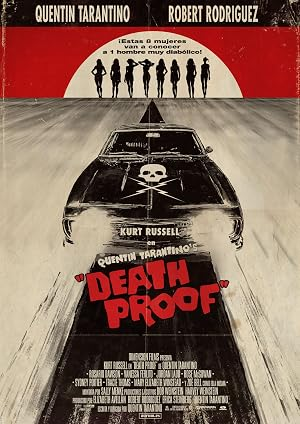

In [123]:
import requests
from PIL import Image
from io import BytesIO

test_url = movie_with_posters["poster"].dropna().iloc[0]

response = requests.get(test_url, timeout=10)

print("Status code:", response.status_code)

image = Image.open(
    BytesIO(response.content)
).convert("RGB")

print("Image size:", image.size)

display(image)

In [124]:
import numpy as np
import pandas as pd
import requests
import torch

from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm

# --------------------------------------------------
# Prepare movies that have posters
# --------------------------------------------------

poster_movies = movie_with_posters[
    movie_with_posters["poster"].notna()
].copy()

print("Movies to process:", len(poster_movies))


# --------------------------------------------------
# Function to download an image
# --------------------------------------------------

def download_image(url):
    try:
        response = requests.get(
            url,
            timeout=10
        )

        if response.status_code != 200:
            return None

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGB")

        return image

    except Exception:
        return None


# --------------------------------------------------
# Generate CLIP embeddings
# --------------------------------------------------

image_embeddings = []
valid_movie_ids = []
failed_movies = []

batch_size = 32

for start in tqdm(
    range(0, len(poster_movies), batch_size),
    desc="Generating CLIP embeddings"
):

    batch = poster_movies.iloc[
        start:start + batch_size
    ]

    images = []
    batch_movie_ids = []

    for _, row in batch.iterrows():

        image = download_image(row["poster"])

        if image is not None:
            images.append(image)
            batch_movie_ids.append(row["movieId"])
        else:
            failed_movies.append(row["movieId"])

    # Skip batch if every image failed
    if len(images) == 0:
        continue

    # Prepare images for CLIP
    inputs = clip_processor(
        images=images,
        return_tensors="pt"
    )

    # Move tensors to GPU
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # Generate embeddings
    with torch.no_grad():

        # The get_image_features method in some versions/configurations
        # returns a BaseModelOutputWithPooling object. We need to extract
        # the actual tensor from its `pooler_output` attribute.
        image_features_output = clip_model.get_image_features(
            **inputs
        )
        image_features = image_features_output.pooler_output

        # Normalize embeddings
        image_features = image_features / image_features.norm(
            dim=-1,
            keepdim=True
        )

    # Move embeddings back to CPU
    image_embeddings.append(
        image_features.cpu().numpy()
    )

    valid_movie_ids.extend(batch_movie_ids)


# --------------------------------------------------
# Combine all embeddings
# --------------------------------------------------

image_embeddings = np.vstack(image_embeddings)

valid_movie_ids = np.array(valid_movie_ids)

print("\nCLIP extraction completed!")

print(
    "Embedding matrix shape:",
    image_embeddings.shape
)

print(
    "Movies successfully embedded:",
    len(valid_movie_ids)
)

print(
    "Failed downloads:",
    len(failed_movies)
)

Movies to process: 2044


Generating CLIP embeddings:   0%|          | 0/64 [00:00<?, ?it/s]


CLIP extraction completed!
Embedding matrix shape: (1817, 512)
Movies successfully embedded: 1817
Failed downloads: 227


In [125]:
print("movie_with_posters:", len(movie_with_posters))

print(
    "Movies with posters:",
    movie_with_posters["poster"].notna().sum()
)

print(
    "Unique movie IDs:",
    movie_with_posters["movieId"].nunique()
)

print(
    "Unique IMDb IDs:",
    movie_with_posters["imdbId"].nunique()
)

movie_with_posters: 9742
Movies with posters: 2044
Unique movie IDs: 9742
Unique IMDb IDs: 9742


In [126]:
print("movie_data shape:", movie_data.shape)

print(
    "Unique movie IDs:",
    movie_data["movieId"].nunique()
)

print(
    "Unique IMDb IDs:",
    movie_data["imdbId"].nunique()
)

movie_data shape: (9742, 29)
Unique movie IDs: 9742
Unique IMDb IDs: 9742


In [127]:
print("MovieLens movie IDs:")
print(movie_data["movieId"].head(20).tolist())

print("\nPoster dataset movie IDs:")
print(poster_df["movie_id"].head(20).tolist())

MovieLens movie IDs:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

Poster dataset movie IDs:
[2602, 2029, 6465, 3037, 7592, 1897, 2126, 5939, 510, 7445, 484, 7074, 9035, 1158, 6291, 2999, 1438, 254, 1067, 1765]


In [128]:
print("\nMovieLens IMDb IDs:")
print(movie_data["imdbId"].head(10).tolist())

print("\nPoster IMDb IDs:")
print(poster_df["imdbId"].head(10).tolist())


MovieLens IMDb IDs:
['tt114709', 'tt113497', 'tt113228', 'tt114885', 'tt113041', 'tt113277', 'tt114319', 'tt112302', 'tt114576', 'tt113189']

Poster IMDb IDs:
['tt0146882', 'tt0120891', 'tt0478311', 'tt0186589', 'tt1605783', 'tt0071110', 'tt0120657', 'tt0379786', 'tt0096895', 'tt1458175']


In [129]:
def normalize_imdb_id(imdb_id):
    if pd.isna(imdb_id):
        return None

    imdb_id = str(imdb_id).strip()

    if imdb_id.startswith("tt"):
        number = imdb_id[2:].lstrip("0")

        # Keep at least one digit
        if number == "":
            number = "0"

        return "tt" + number

    return imdb_id


movie_data["imdbId_normalized"] = (
    movie_data["imdbId"]
    .apply(normalize_imdb_id)
)

poster_df["imdbId_normalized"] = (
    poster_df["imdbId"]
    .apply(normalize_imdb_id)
)

In [130]:
poster_imdb_ids = set(
    poster_df["imdbId_normalized"].dropna()
)

movie_imdb_ids = set(
    movie_data["imdbId_normalized"].dropna()
)

matching_ids = movie_imdb_ids.intersection(
    poster_imdb_ids
)

print("MovieLens IMDb IDs:", len(movie_imdb_ids))
print("Poster IMDb IDs:", len(poster_imdb_ids))
print("Matching IMDb IDs:", len(matching_ids))

MovieLens IMDb IDs: 9742
Poster IMDb IDs: 9366
Matching IMDb IDs: 9366


In [131]:
poster_unique = poster_df[
    ["imdbId_normalized", "poster"]
].drop_duplicates(
    subset="imdbId_normalized"
)

movie_with_posters = movie_data.merge(
    poster_unique,
    on="imdbId_normalized",
    how="left"
)

print("Total movies:", len(movie_with_posters))

print(
    "Movies with posters:",
    movie_with_posters["poster"].notna().sum()
)

print(
    "Movies without posters:",
    movie_with_posters["poster"].isna().sum()
)

Total movies: 9742
Movies with posters: 9366
Movies without posters: 376


In [132]:
poster_movies = movie_with_posters[
    movie_with_posters["poster"].notna()
].copy()

print("Movies to process:", len(poster_movies))

Movies to process: 9366


In [134]:
import numpy as np
import pandas as pd
import requests
import torch

from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm

# -----------------------------------------
# Prepare movie data
# -----------------------------------------

poster_movies = movie_with_posters[
    movie_with_posters["poster"].notna()
].copy()

print("Movies to process:", len(poster_movies))


# -----------------------------------------
# Download image
# -----------------------------------------

def download_image(url):
    try:
        response = requests.get(
            url,
            timeout=10
        )

        if response.status_code != 200:
            return None

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGB")

        return image

    except Exception:
        return None


# -----------------------------------------
# Generate CLIP embeddings
# -----------------------------------------

image_embeddings = []
valid_movie_ids = []
failed_movies = []

batch_size = 32

for start in tqdm(
    range(0, len(poster_movies), batch_size),
    desc="Generating CLIP embeddings"
):

    batch = poster_movies.iloc[
        start:start + batch_size
    ]

    images = []
    batch_movie_ids = []

    for _, row in batch.iterrows():

        image = download_image(row["poster"])

        if image is not None:

            images.append(image)

            batch_movie_ids.append(
                row["movieId"]
            )

        else:

            failed_movies.append(
                row["movieId"]
            )

    # If every image in this batch failed
    if len(images) == 0:
        continue

    # -----------------------------------------
    # Process images using CLIP
    # -----------------------------------------

    inputs = clip_processor(
        images=images,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    # -----------------------------------------
    # Generate embeddings
    # -----------------------------------------

    with torch.no_grad():

        image_features_output = clip_model.get_image_features(
            **inputs
        )
        # Access the actual tensor from the BaseModelOutputWithPooling object
        image_features = image_features_output.pooler_output

        # Normalize embeddings
        image_features = (
            image_features /
            image_features.norm(
                dim=-1,
                keepdim=True
            )
        )

    # Move to CPU
    image_embeddings.append(
        image_features.cpu().numpy()
    )

    valid_movie_ids.extend(
        batch_movie_ids
    )


# -----------------------------------------
# Combine embeddings
# -----------------------------------------

image_embeddings = np.vstack(
    image_embeddings
)

valid_movie_ids = np.array(
    valid_movie_ids
)

print("\nCLIP extraction completed!")

print(
    "Embedding matrix shape:",
    image_embeddings.shape
)

print(
    "Movies successfully embedded:",
    len(valid_movie_ids)
)

print(
    "Failed downloads:",
    len(failed_movies)
)

Movies to process: 9366


Generating CLIP embeddings:   0%|          | 0/293 [00:00<?, ?it/s]


CLIP extraction completed!
Embedding matrix shape: (8148, 512)
Movies successfully embedded: 8148
Failed downloads: 1218


In [135]:
np.save(
    "movie_image_embeddings.npy",
    image_embeddings
)

np.save(
    "movie_image_movie_ids.npy",
    valid_movie_ids
)

print("CLIP embeddings saved successfully!")

CLIP embeddings saved successfully!


In [136]:
print(
    "Number of embeddings:",
    len(image_embeddings)
)

print(
    "Number of movie IDs:",
    len(valid_movie_ids)
)

print(
    "Embedding dimensions:",
    image_embeddings.shape[1]
)

Number of embeddings: 8148
Number of movie IDs: 8148
Embedding dimensions: 512


In [137]:
text_embeddings = np.load("movie_text_embeddings.npy")

print("Text embedding shape:", text_embeddings.shape)

Text embedding shape: (9742, 384)


In [138]:
print("Number of movie IDs:", len(movie_data))
print("Number of text embeddings:", len(text_embeddings))

Number of movie IDs: 9742
Number of text embeddings: 9742


In [139]:
import numpy as np
import pandas as pd

# Load saved CLIP data
image_embeddings = np.load("movie_image_embeddings.npy")
image_movie_ids = np.load("movie_image_movie_ids.npy")

print("Image embeddings:", image_embeddings.shape)
print("Image movie IDs:", image_movie_ids.shape)

# Create lookup:
# movieId -> CLIP embedding
image_embedding_dict = {
    int(movie_id): embedding
    for movie_id, embedding
    in zip(image_movie_ids, image_embeddings)
}

# CLIP dimension
image_dim = image_embeddings.shape[1]

# Create aligned image matrix for ALL 9742 movies
aligned_image_embeddings = np.zeros(
    (len(movie_data), image_dim),
    dtype=np.float32
)

# Track whether image exists
image_available = np.zeros(
    len(movie_data),
    dtype=np.float32
)

for idx, movie_id in enumerate(movie_data["movieId"]):

    if int(movie_id) in image_embedding_dict:

        aligned_image_embeddings[idx] = (
            image_embedding_dict[int(movie_id)]
        )

        image_available[idx] = 1.0

print("\nAligned image embeddings:")
print(aligned_image_embeddings.shape)

print(
    "Movies with CLIP embeddings:",
    int(image_available.sum())
)

print(
    "Movies without CLIP embeddings:",
    int((image_available == 0).sum())
)

Image embeddings: (8148, 512)
Image movie IDs: (8148,)

Aligned image embeddings:
(9742, 512)
Movies with CLIP embeddings: 8148
Movies without CLIP embeddings: 1594


In [140]:
np.save(
    "aligned_image_embeddings.npy",
    aligned_image_embeddings
)

np.save(
    "image_available.npy",
    image_available
)

print("Aligned CLIP embeddings saved!")

Aligned CLIP embeddings saved!


In [141]:
genre_columns = [
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "IMAX",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western"
]

genre_features = movie_data[
    genre_columns
].fillna(0).values.astype(np.float32)

print("Genre features shape:", genre_features.shape)

Genre features shape: (9742, 19)


In [142]:
import torch

checkpoint = torch.load(
    "ncf_model.pth",
    map_location=device
)

print(type(checkpoint))

<class 'collections.OrderedDict'>


In [144]:
import torch
import torch.nn as nn

# Recreate the NCF architecture
class NCF(nn.Module):
    def __init__(self, num_users, num_movies, embedding_dim=64):
        super().__init__()

        self.user_embedding = nn.Embedding(
            num_users,
            embedding_dim
        )

        self.movie_embedding = nn.Embedding(
            num_movies,
            embedding_dim
        )

        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, user_ids, movie_ids):

        user_emb = self.user_embedding(user_ids)
        movie_emb = self.movie_embedding(movie_ids)

        x = torch.cat(
            [user_emb, movie_emb],
            dim=1
        )

        return self.mlp(x)


# Create model
ncf_model = NCF(
    num_users=len(user_ids),
    num_movies=len(train_movie_ids), # Changed from len(movie_ids) to len(train_movie_ids)
    embedding_dim=64
)

# Load trained weights
ncf_model.load_state_dict(checkpoint)

ncf_model = ncf_model.to(device)

ncf_model.eval()

print("NCF model loaded successfully!")
print("User embedding:", ncf_model.user_embedding.weight.shape)
print("Movie embedding:", ncf_model.movie_embedding.weight.shape)

NCF model loaded successfully!
User embedding: torch.Size([610, 64])
Movie embedding: torch.Size([9701, 64])


9. Genre Feature Engineering

In [145]:
# Movies actually present in the interaction dataset
model_movie_ids = np.array(movie_ids)

# Create lookup from movieId -> row in movie_features
movie_feature_lookup = {
    int(movie_id): idx
    for idx, movie_id in enumerate(movie_data["movieId"])
}

# Find feature rows corresponding to our 9701 movies
feature_indices = [
    movie_feature_lookup[int(movie_id)]
    for movie_id in model_movie_ids
]

# Text features
model_text_embeddings = text_embeddings[
    feature_indices
].astype(np.float32)

# Image features
model_image_embeddings = aligned_image_embeddings[
    feature_indices
].astype(np.float32)

# Genre features
model_genre_features = genre_features[
    feature_indices
].astype(np.float32)

# Image availability
model_image_available = image_available[
    feature_indices
].astype(np.float32)


print("Text:", model_text_embeddings.shape)
print("Image:", model_image_embeddings.shape)
print("Genres:", model_genre_features.shape)
print("Image availability:", model_image_available.shape)

Text: (9724, 384)
Image: (9724, 512)
Genres: (9724, 19)
Image availability: (9724,)


In [146]:
class TwoTowerModel(nn.Module):

    def __init__(
        self,
        num_users,
        text_dim=384,
        image_dim=512,
        genre_dim=19,
        user_dim=64,
        tower_dim=128
    ):

        super().__init__()

        # -------------------------
        # USER TOWER
        # -------------------------

        self.user_embedding = nn.Embedding(
            num_users,
            user_dim
        )

        self.user_tower = nn.Sequential(
            nn.Linear(user_dim, 128),
            nn.ReLU(),
            nn.Linear(128, tower_dim)
        )

        # -------------------------
        # MOVIE TOWER
        # -------------------------

        self.movie_tower = nn.Sequential(

            nn.Linear(
                text_dim + image_dim + genre_dim + 1,
                512
            ),

            nn.ReLU(),

            nn.Linear(
                512,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                tower_dim
            )
        )

    def get_user_embedding(self, user_ids):

        user_emb = self.user_embedding(user_ids)

        return self.user_tower(user_emb)

    def get_movie_embedding(
        self,
        text_features,
        image_features,
        genre_features,
        image_available
    ):

        image_available = image_available.unsqueeze(1)

        movie_features = torch.cat(
            [
                text_features,
                image_features,
                genre_features,
                image_available
            ],
            dim=1
        )

        return self.movie_tower(movie_features)

    def forward(
        self,
        user_ids,
        text_features,
        image_features,
        genre_features,
        image_available
    ):

        user_vector = self.get_user_embedding(
            user_ids
        )

        movie_vector = self.get_movie_embedding(
            text_features,
            image_features,
            genre_features,
            image_available
        )

        # Normalize vectors
        user_vector = nn.functional.normalize(
            user_vector,
            p=2,
            dim=1
        )

        movie_vector = nn.functional.normalize(
            movie_vector,
            p=2,
            dim=1
        )

        # Cosine similarity
        score = torch.sum(
            user_vector * movie_vector,
            dim=1
        )

        return score

10. Model 3 — Two-Tower Multimodal Model

In [147]:
two_tower = TwoTowerModel(
    num_users=len(user_ids),
    text_dim=384,
    image_dim=512,
    genre_dim=19,
    user_dim=64,
    tower_dim=128
)

two_tower = two_tower.to(device)

print(two_tower)

TwoTowerModel(
  (user_embedding): Embedding(610, 64)
  (user_tower): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (movie_tower): Sequential(
    (0): Linear(in_features=916, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
  )
)


In [148]:
print("len(movie_ids):", len(movie_ids))
print("len(user_ids):", len(user_ids))

print("NCF movie embeddings:",
      ncf_model.movie_embedding.num_embeddings)

print("Text embeddings:", text_embeddings.shape)
print("Movie data:", movie_data.shape)

print("\nFirst 20 movie_ids:")
print(movie_ids[:20])

print("\nNumber of unique movie IDs:")
print(len(set(movie_ids)))

len(movie_ids): 9724
len(user_ids): 610
NCF movie embeddings: 9701
Text embeddings: (9742, 384)
Movie data: (9742, 30)

First 20 movie_ids:
[  1   3   6  47  50  70 101 110 151 157 163 216 223 231 235 260 296 316
 333 349]

Number of unique movie IDs:
9724


In [149]:
# Reload the ratings data to make sure we use the original interaction dataset
ratings_original = pd.read_csv("ratings_processed.csv")

# Recreate the exact movie IDs used by the interaction matrix
ncf_movie_ids = ratings_original["movieId"].unique()

print("Original NCF movie IDs:", len(ncf_movie_ids))
print("First 20:", ncf_movie_ids[:20])

Original NCF movie IDs: 9724
First 20: [  1   3   6  47  50  70 101 110 151 157 163 216 223 231 235 260 296 316
 333 349]


In [150]:
ncf_movie_to_idx = {
    int(movie_id): idx
    for idx, movie_id in enumerate(ncf_movie_ids)
}

print("Mapping size:", len(ncf_movie_to_idx))

Mapping size: 9724


11. Multimodal Feature Alignment

In [151]:
# Lookup in movie_features.csv
movie_feature_lookup = {
    int(movie_id): idx
    for idx, movie_id in enumerate(movie_data["movieId"])
}

# Find rows for the exact 9701 NCF movies
feature_indices = [
    movie_feature_lookup[int(movie_id)]
    for movie_id in ncf_movie_ids
]

# Text
model_text_embeddings = text_embeddings[
    feature_indices
].astype(np.float32)

# Image
model_image_embeddings = aligned_image_embeddings[
    feature_indices
].astype(np.float32)

# Genres
model_genre_features = genre_features[
    feature_indices
].astype(np.float32)

# Image availability
model_image_available = image_available[
    feature_indices
].astype(np.float32)


print("Text:", model_text_embeddings.shape)
print("Image:", model_image_embeddings.shape)
print("Genres:", model_genre_features.shape)
print("Image availability:", model_image_available.shape)

Text: (9724, 384)
Image: (9724, 512)
Genres: (9724, 19)
Image availability: (9724,)


In [152]:
print("Interaction matrix shape:", interaction_matrix.shape)
print("Current movie IDs:", len(movie_ids))
print("Saved NCF movie embeddings:",
      ncf_model.movie_embedding.num_embeddings)

Interaction matrix shape: (610, 9724)
Current movie IDs: 9724
Saved NCF movie embeddings: 9701


In [153]:
# Check whether the current movie IDs can be reduced
# to exactly the number expected by NCF

print("First movie ID:", movie_ids[0])
print("Last movie ID:", movie_ids[-1])

print("Number of movie IDs:", len(movie_ids))

First movie ID: 1
Last movie ID: 163981
Number of movie IDs: 9724


In [154]:
print("Total ratings:", len(ratings))
print("Training ratings:", len(train_ratings))
print("Test ratings:", len(test_ratings))

print("Training users:", train_ratings["userId"].nunique())
print("Test users:", test_ratings["userId"].nunique())

print("Unique training movies:", train_ratings["movieId"].nunique())
print("Unique total movies:", ratings["movieId"].nunique())

Total ratings: 100836
Training ratings: 100226
Test ratings: 610
Training users: 610
Test users: 610
Unique training movies: 9701
Unique total movies: 9724


In [155]:
print("Training interaction matrix currently:",
      interaction_matrix.shape)

Training interaction matrix currently: (610, 9724)


In [156]:
# Exact movie IDs used during training
train_movie_ids = np.sort(
    train_ratings["movieId"].unique()
)

print("Training movie IDs:", len(train_movie_ids))
print("First 20:", train_movie_ids[:20])

Training movie IDs: 9701
First 20: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [157]:
train_movie_to_idx = {
    int(movie_id): idx
    for idx, movie_id in enumerate(train_movie_ids)
}

print("Training movie mapping:", len(train_movie_to_idx))

Training movie mapping: 9701


In [158]:
feature_lookup = {
    int(movie_id): idx
    for idx, movie_id in enumerate(movie_data["movieId"])
}

train_feature_indices = [
    feature_lookup[int(movie_id)]
    for movie_id in train_movie_ids
]

train_text_embeddings = text_embeddings[
    train_feature_indices
].astype(np.float32)

train_image_embeddings = aligned_image_embeddings[
    train_feature_indices
].astype(np.float32)

train_genre_features = genre_features[
    train_feature_indices
].astype(np.float32)

train_image_available = image_available[
    train_feature_indices
].astype(np.float32)

print("Training text:", train_text_embeddings.shape)
print("Training image:", train_image_embeddings.shape)
print("Training genres:", train_genre_features.shape)
print("Training image availability:",
      train_image_available.shape)

Training text: (9701, 384)
Training image: (9701, 512)
Training genres: (9701, 19)
Training image availability: (9701,)


In [159]:
with torch.no_grad():
    two_tower.user_embedding.weight.copy_(
        ncf_model.user_embedding.weight
    )

print("User embeddings initialized from trained NCF!")

User embeddings initialized from trained NCF!


In [160]:
import torch
from torch.utils.data import Dataset, DataLoader

# Convert user IDs to model indices
train_user_indices = train_ratings["userId"].map(
    {user_id: idx for idx, user_id in enumerate(user_ids)}
).values

# Convert movie IDs to training movie indices
train_movie_indices = train_ratings["movieId"].map(
    train_movie_to_idx
).values

train_ratings_values = train_ratings["rating"].values.astype(np.float32)

print("Users:", len(train_user_indices))
print("Movies:", len(train_movie_indices))
print("Ratings:", len(train_ratings_values))

Users: 100226
Movies: 100226
Ratings: 100226


In [161]:
class RecommendationDataset(Dataset):

    def __init__(self, users, movies, ratings):
        self.users = torch.tensor(users, dtype=torch.long)
        self.movies = torch.tensor(movies, dtype=torch.long)
        self.ratings = torch.tensor(ratings, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            self.users[idx],
            self.movies[idx],
            self.ratings[idx]
        )


train_dataset = RecommendationDataset(
    train_user_indices,
    train_movie_indices,
    train_ratings_values
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

print("Dataset size:", len(train_dataset))
print("Number of batches:", len(train_loader))

Dataset size: 100226
Number of batches: 392


In [162]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

two_tower = two_tower.to(device)

print("Using device:", device)

Using device: cuda


In [163]:
text_tensor = torch.tensor(
    train_text_embeddings,
    dtype=torch.float32
).to(device)

image_tensor = torch.tensor(
    train_image_embeddings,
    dtype=torch.float32
).to(device)

genre_tensor = torch.tensor(
    train_genre_features,
    dtype=torch.float32
).to(device)

image_available_tensor = torch.tensor(
    train_image_available,
    dtype=torch.float32
).to(device)

print("Text:", text_tensor.shape)
print("Image:", image_tensor.shape)
print("Genres:", genre_tensor.shape)
print("Image availability:", image_available_tensor.shape)

Text: torch.Size([9701, 384])
Image: torch.Size([9701, 512])
Genres: torch.Size([9701, 19])
Image availability: torch.Size([9701])


12. Two-Tower Model Training

In [164]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

criterion = nn.MSELoss()

optimizer = optim.Adam(
    two_tower.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    two_tower.train()

    total_loss = 0

    for users, movies, ratings_batch in train_loader:

        users = users.to(device)
        movies = movies.to(device)
        ratings_batch = ratings_batch.to(device)

        # User representation
        user_vector = two_tower.user_tower(
            two_tower.user_embedding(users)
        )

        # Movie features
        movie_features_batch = torch.cat(
            [
                text_tensor[movies],
                image_tensor[movies],
                genre_tensor[movies],
                image_available_tensor[movies].unsqueeze(1)
            ],
            dim=1
        )

        # Movie representation
        movie_vector = two_tower.movie_tower(
            movie_features_batch
        )

        # Normalize vectors
        user_vector = F.normalize(
            user_vector,
            p=2,
            dim=1
        )

        movie_vector = F.normalize(
            movie_vector,
            p=2,
            dim=1
        )

        # Similarity score
        predicted_score = torch.sum(
            user_vector * movie_vector,
            dim=1
        )

        # Convert similarity from [-1, 1] to approximately [0, 5]
        predicted_rating = (
            predicted_score + 1
        ) * 2.5

        loss = criterion(
            predicted_rating,
            ratings_batch
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {average_loss:.4f}"
    )

Epoch 1/10 - Loss: 0.8268
Epoch 2/10 - Loss: 0.7184
Epoch 3/10 - Loss: 0.6702
Epoch 4/10 - Loss: 0.6348
Epoch 5/10 - Loss: 0.6039
Epoch 6/10 - Loss: 0.5759
Epoch 7/10 - Loss: 0.5504
Epoch 8/10 - Loss: 0.5283
Epoch 9/10 - Loss: 0.5075
Epoch 10/10 - Loss: 0.4904


In [165]:
torch.save(
    two_tower.state_dict(),
    "two_tower_model.pth"
)

print("Two-Tower model saved successfully!")

Two-Tower model saved successfully!


13. Ensemble Recommendation Layer

In [166]:
import numpy as np

def min_max_normalize(scores):
    scores = np.asarray(scores, dtype=np.float32)

    min_score = scores.min()
    max_score = scores.max()

    if max_score == min_score:
        return np.zeros_like(scores)

    return (scores - min_score) / (max_score - min_score)


def ensemble_scores(
    nmf_scores,
    ncf_scores,
    two_tower_scores,
    nmf_weight=0.30,
    ncf_weight=0.35,
    two_tower_weight=0.35
):
    # Normalize each model's scores
    nmf_norm = min_max_normalize(nmf_scores)
    ncf_norm = min_max_normalize(ncf_scores)
    two_tower_norm = min_max_normalize(two_tower_scores)

    # Weighted ensemble
    final_scores = (
        nmf_weight * nmf_norm +
        ncf_weight * ncf_norm +
        two_tower_weight * two_tower_norm
    )

    return final_scores

In [167]:
weights = [0.30, 0.35, 0.35]

print("Weight sum:", sum(weights))

Weight sum: 1.0


In [168]:
def get_ensemble_recommendations(
    nmf_scores,
    ncf_scores,
    two_tower_scores,
    movie_ids,
    movie_data,
    top_k=10
):
    # Calculate final ensemble scores
    final_scores = ensemble_scores(
        nmf_scores,
        ncf_scores,
        two_tower_scores,
        nmf_weight=0.30,
        ncf_weight=0.35,
        two_tower_weight=0.35
    )

    # Create result DataFrame
    results = pd.DataFrame({
        "movieId": movie_ids,
        "NMF_Score": nmf_scores,
        "NCF_Score": ncf_scores,
        "TwoTower_Score": two_tower_scores,
        "Ensemble_Score": final_scores
    })

    # Add movie titles
    results = results.merge(
        movie_data[["movieId", "title"]],
        on="movieId",
        how="left"
    )

    # Sort by final ensemble score
    results = results.sort_values(
        "Ensemble_Score",
        ascending=False
    )

    # Return top K
    return results.head(top_k)

In [169]:
print("NMF model:", type(nmf_model))
print("NCF model:", type(ncf_model))
print("Two-Tower model:", type(two_tower))

print("Number of movie IDs:", len(movie_ids))
print("Number of training movie IDs:", len(train_movie_ids))

NMF model: <class 'sklearn.decomposition._nmf.NMF'>
NCF model: <class '__main__.NCF'>
Two-Tower model: <class '__main__.TwoTowerModel'>
Number of movie IDs: 9724
Number of training movie IDs: 9701


In [171]:
# ============================================
# ENSEMBLE INTEGRATION TEST
# ============================================

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd

# Select a user for testing
test_user_id = 1

# Convert user ID to NCF index
user_idx = user_to_idx[test_user_id]

print("Testing User ID:", test_user_id)
print("User index:", user_idx)

# --------------------------------------------
# 1. NMF SCORES
# --------------------------------------------

# Get NMF scores for the test user from pre-calculated predicted_ratings.
# predicted_ratings has shape (num_users, num_train_movies), so it's
# already aligned with the NMF model's training movie set.
nmf_scores = predicted_ratings[user_idx].flatten()

print("NMF scores:", nmf_scores.shape)


# --------------------------------------------
# 2. NCF SCORES
# --------------------------------------------

ncf_model.eval()

with torch.no_grad():

    user_tensor = torch.tensor(
        [user_idx] * len(train_movie_ids),
        dtype=torch.long
    ).to(device)

    movie_tensor = torch.tensor(
        list(range(len(train_movie_ids))),
        dtype=torch.long
    ).to(device)

    ncf_scores = ncf_model(
        user_tensor,
        movie_tensor
    ).squeeze().cpu().numpy()

print("NCF scores:", ncf_scores.shape)


# --------------------------------------------
# 3. TWO-TOWER SCORES
# --------------------------------------------

two_tower.eval()

with torch.no_grad():

    # User vector
    user_input = torch.tensor(
        [user_idx],
        dtype=torch.long
    ).to(device)

    user_vector = two_tower.user_tower(
        two_tower.user_embedding(user_input)
    )

    # Repeat user vector for all movies
    user_vector = user_vector.repeat(
        len(train_movie_ids), 1
    )

    # Movie features
    movie_features = torch.cat(
        [
            text_tensor,
            image_tensor,
            genre_tensor,
            image_available_tensor.unsqueeze(1)
        ],
        dim=1
    )

    movie_vector = two_tower.movie_tower(
        movie_features
    )

    # Normalize
    user_vector = F.normalize(
        user_vector,
        p=2,
        dim=1
    )

    movie_vector = F.normalize(
        movie_vector,
        p=2,
        dim=1
    )

    # Cosine similarity
    two_tower_scores = torch.sum(
        user_vector * movie_vector,
        dim=1
    )

    two_tower_scores = two_tower_scores.cpu().numpy()

print("Two-Tower scores:", two_tower_scores.shape)


# --------------------------------------------
# CHECK
# --------------------------------------------

print("\n========== SCORE CHECK ==========")
print("NMF:", len(nmf_scores))
print("NCF:", len(ncf_scores))
print("Two-Tower:", len(two_tower_scores))

Testing User ID: 1
User index: 0
NMF scores: (9701,)
NCF scores: (9701,)
Two-Tower scores: (9701,)

========== SCORE CHECK ==========
NMF: 9701
NCF: 9701
Two-Tower: 9701


14. Ensemble Recommendation Output

In [172]:
ensemble_result = get_ensemble_recommendations(
    nmf_scores=nmf_scores,
    ncf_scores=ncf_scores,
    two_tower_scores=two_tower_scores,
    movie_ids=train_movie_ids,
    movie_data=movie_data,
    top_k=10
)

ensemble_result

,movieId,NMF_Score,NCF_Score,TwoTower_Score,Ensemble_Score,title
46,50,4.818288,5.046161,0.842675,0.875456,"Usual Suspects, The (1995)"
83,94,4.260621,4.857757,0.747365,0.795312,Beautiful Girls (1996)
1,2,4.500705,4.782735,0.704781,0.789675,Jumanji (1995)
69,77,5.028493,4.598496,0.490765,0.741513,Nico Icon (1995)
15,16,3.010385,4.674891,0.864545,0.733916,Casino (1995)
70,78,4.147386,4.657724,0.626171,0.733193,"Crossing Guard, The (1995)"
77,86,3.580826,4.394030,0.827775,0.727548,White Squall (1996)
468,536,3.801650,4.464466,0.739352,0.723526,"Simple Twist of Fate, A (1994)"
10,11,3.095672,4.913645,0.678982,0.712664,"American President, The (1995)"
208,242,3.160857,4.767682,0.719901,0.712358,Farinelli: il castrato (1994)


Multi-Modal Recommendation System

This notebook implements the model architecture for a multi-modal movie recommendation system combining:


- Collaborative Filtering using NMF
- Neural Collaborative Filtering (NCF)
- Text embeddings using Sentence-BERT
- Image embeddings using CLIP
- Genre features
- A Two-Tower multimodal recommendation model
- A weighted ensemble combining the recommendation signals